# 🎯 Customer Segmentation Analysis
**Oasis Infobyte SIP — Data Analytics Track — Level 1, Task 2**

**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Dataset:** [Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (UCI Machine Learning Repository) — over 1 million transactions from a UK-based online gift retailer, spanning December 2009 to December 2011.

**Approach:** RFM (Recency, Frequency, Monetary) analysis — the industry-standard framework for behavioural customer segmentation — followed by K-Means clustering.

## 1. Load Dataset & Inspect Structure

In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'  # silences a harmless joblib/Windows CPU-detection warning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('online_retail_II.csv', parse_dates=['InvoiceDate'])
print("Shape:", df.shape)
df.head()


Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
print("Column dtypes:")
print(df.dtypes)
print("\nNull values:")
print(df.isnull().sum())
print(f"\nDate range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")


Column dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Null values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


**Observation:** The raw dataset has **1,067,371 transaction line-items**. `Customer ID` has **243,007 missing values** — these are guest/unregistered purchases that cannot be tied to an individual customer, so they must be dropped before segmentation. `Description` also has a small number of nulls (product name missing), which doesn't affect this analysis since we only need price and quantity.

## 2. Handle Missing Values & Inconsistent Data

In [3]:
# Drop rows with no Customer ID — can't segment a customer we can't identify
df_clean = df.dropna(subset=['Customer ID']).copy()

# Invoice numbers starting with 'C' are cancellations/returns — exclude them
cancellations = df_clean['Invoice'].astype(str).str.startswith('C').sum()
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Remove non-positive quantity or price (data entry errors, adjustments)
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
df_clean['Amount'] = df_clean['Quantity'] * df_clean['Price']

print(f"Cancellation invoices removed: {cancellations}")
print(f"Rows after all cleaning: {len(df_clean):,} (started with {len(df):,})")
print(f"Unique customers remaining: {df_clean['Customer ID'].nunique():,}")


Cancellation invoices removed: 18744
Rows after all cleaning: 805,549 (started with 1,067,371)
Unique customers remaining: 5,878


**Observation:** After removing guest checkouts, cancelled orders, and invalid quantity/price rows, the cleaned dataset retains **805,549 transaction lines** across **5,878 identifiable customers** — a solid base for behavioural segmentation.

## 3. Descriptive Statistics: Purchase Value, Frequency & Customer Lifetime Value

In [4]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Amount', 'sum')
).reset_index()

print(f"Analysis snapshot date: {snapshot_date.date()} (day after the last transaction in the data)\n")
print("RFM summary statistics:")
rfm[['Recency', 'Frequency', 'Monetary']].describe()


Analysis snapshot date: 2011-12-10 (day after the last transaction in the data)

RFM summary statistics:


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


In [5]:
avg_txn_value = df_clean['Amount'].sum() / df_clean['Invoice'].nunique()
avg_purchase_freq = rfm['Frequency'].mean()
avg_clv = rfm['Monetary'].mean()
median_clv = rfm['Monetary'].median()

print(f"Average transaction value: £{avg_txn_value:,.2f}")
print(f"Average purchase frequency per customer: {avg_purchase_freq:.1f} orders")
print(f"Average Customer Lifetime Value (total spend): £{avg_clv:,.2f}")
print(f"Median Customer Lifetime Value: £{median_clv:,.2f}")


Average transaction value: £479.95
Average purchase frequency per customer: 6.3 orders
Average Customer Lifetime Value (total spend): £3,018.62
Median Customer Lifetime Value: £898.91


**Observation:** The average transaction value is **£479.95**, average purchase frequency is **6.3 orders per customer** over the 2-year window, and average CLV is **£3,018.62** — but the **median CLV is only £898.92**, revealing a heavily right-skewed distribution. A small number of high-volume wholesale-style buyers (max single-customer spend: **£608,821.65**) pull the average well above what a typical customer spends.

## 4. Feature Selection — RFM Analysis

**Recency, Frequency, and Monetary value** were selected as the 3 clustering features because they directly capture the three dimensions that matter most for marketing action: *how recently* a customer engaged, *how often* they buy, and *how much revenue* they represent. Together, these three features let us distinguish loyal high-spenders from one-time or lapsed customers — exactly the distinction a marketing team needs to target campaigns effectively.

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['Recency'], bins=40, ax=axes[0], color='#2563eb')
axes[0].set_title('Recency Distribution (days)')
sns.histplot(rfm['Frequency'], bins=40, ax=axes[1], color='#059669')
axes[1].set_title('Frequency Distribution (orders)')
sns.histplot(rfm['Monetary'], bins=40, ax=axes[2], color='#dc2626')
axes[2].set_title('Monetary Distribution (£)')
plt.tight_layout()
plt.show()


<Figure size 1500x400 with 3 Axes>

**Observation:** All three features are heavily right-skewed (most customers cluster at low values, with a long tail of high spenders/frequent buyers). This skew means raw RFM values would distort K-Means (which relies on Euclidean distance), so a log transform is applied before scaling.

## 5. Data Normalisation / Standardisation

In [7]:
rfm_log = rfm.copy()
rfm_log['Recency_log'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary_log'] = np.log1p(rfm_log['Monetary'])

features = ['Recency_log', 'Frequency_log', 'Monetary_log']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log[features])

print("Scaled feature means (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Scaled feature std devs (should be ~1):", X_scaled.std(axis=0).round(3))


Scaled feature means (should be ~0): [-0.  0. -0.]
Scaled feature std devs (should be ~1): [1. 1. 1.]


**Observation:** A `log1p` transform was applied first to compress the long tails (a common, standard step for monetary/frequency RFM data), then `StandardScaler` was used to put all three features on the same scale — essential for K-Means, which would otherwise let `Monetary` (values in the thousands) dominate `Recency`/`Frequency` (values in single/triple digits) purely due to magnitude, not actual importance.

## 6. K-Means Clustering — Elbow Method

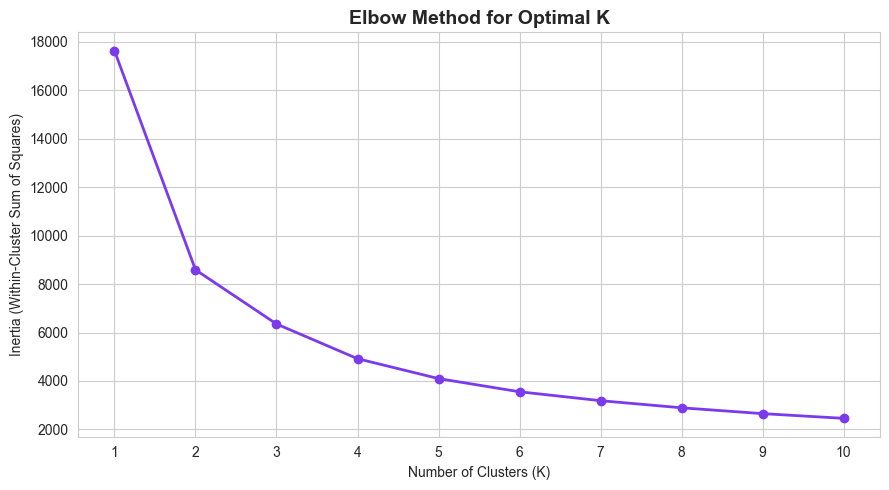

In [8]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inertias, marker='o', linewidth=2, color='#7c3aed')
ax.set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()


In [9]:
from sklearn.metrics import silhouette_score

print("Silhouette scores (higher is better, max 1.0):")
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"  K={k}: {score:.3f}")


Silhouette scores (higher is better, max 1.0):


  K=3: 0.348
  K=4: 0.365
  K=5: 0.342
  K=6: 0.334


**Observation:** The elbow chart shows inertia dropping sharply up to around **K=4**, after which the improvement flattens noticeably. This is confirmed by silhouette scores — **K=4 achieves the highest silhouette score (0.365)** among the candidates tested, better separated than K=3 (0.348), K=5 (0.342), or K=6 (0.334). **K=4 is selected** as the optimal number of clusters.

## 7. Apply Final K-Means Model (K=4)

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(rfm['Cluster'].value_counts().sort_index())


Cluster
0    1188
1    1974
2    1465
3    1251
Name: count, dtype: int64


## 8. Cluster Visualisation — Scatter Plots

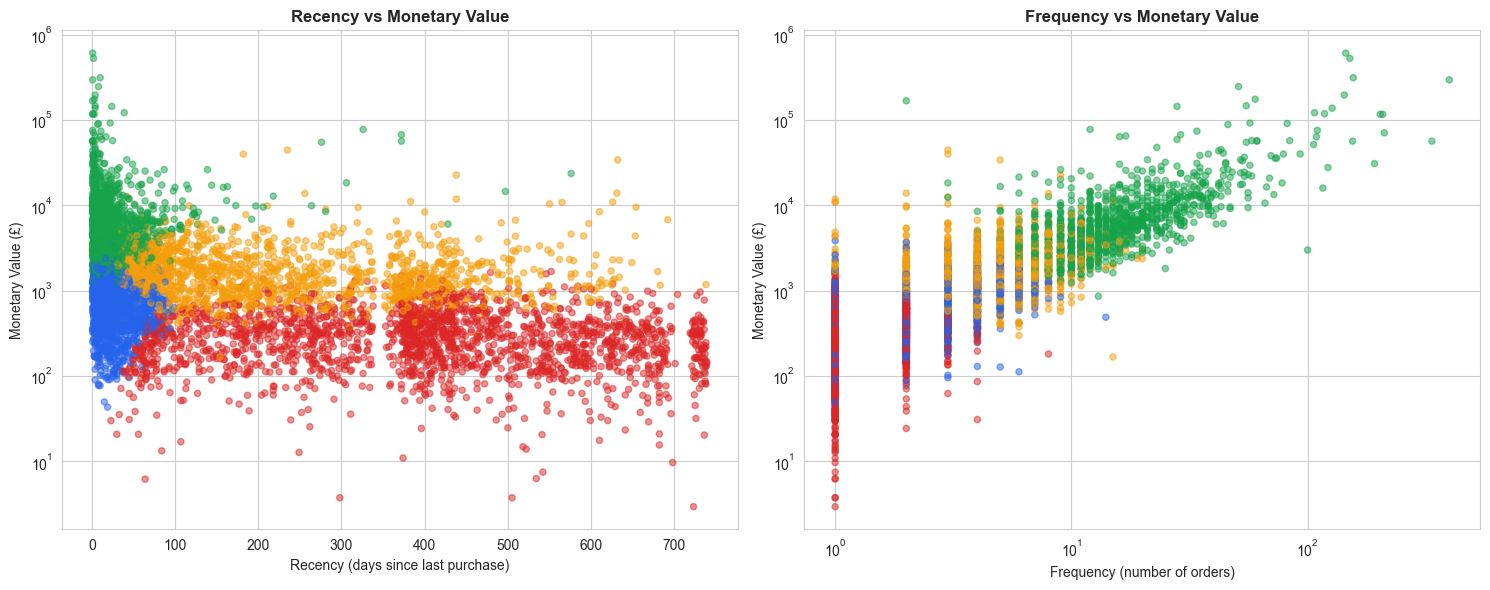

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = {0: '#16a34a', 1: '#dc2626', 2: '#f59e0b', 3: '#2563eb'}
colors = rfm['Cluster'].map(palette)

axes[0].scatter(rfm['Recency'], rfm['Monetary'], c=colors, alpha=0.5, s=20)
axes[0].set_title('Recency vs Monetary Value', fontweight='bold')
axes[0].set_xlabel('Recency (days since last purchase)')
axes[0].set_ylabel('Monetary Value (£)')
axes[0].set_yscale('log')

axes[1].scatter(rfm['Frequency'], rfm['Monetary'], c=colors, alpha=0.5, s=20)
axes[1].set_title('Frequency vs Monetary Value', fontweight='bold')
axes[1].set_xlabel('Frequency (number of orders)')
axes[1].set_ylabel('Monetary Value (£)')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()


**Observation:** Both scatter plots show clearly separated clusters (note the log scale on Monetary, needed given the wide value range). The **Recency vs Monetary** view shows one cluster tightly packed at low recency + high monetary value (loyal, high-value customers), while another cluster is spread across high recency values with low monetary value (customers who haven't purchased in a long time).

## 9. Cluster Profiling

In [12]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('Customer ID', 'count'),
    Avg_Recency_Days=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1)
cluster_profile['Pct_of_Customers'] = (cluster_profile['Customer_Count'] / cluster_profile['Customer_Count'].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values('Avg_Monetary', ascending=False)
cluster_profile


,Customer_Count,Avg_Recency_Days,Avg_Frequency,Avg_Monetary,Pct_of_Customers
Cluster,,,,,
0,1188,27.4,19.3,11014.4,20.2
2,1465,227.9,5.1,2002.1,24.9
3,1251,28.4,3.0,865.1,21.3
1,1974,395.9,1.4,325.7,33.6


**Observation and customer type labels, based on the profile above:**

| Cluster | Recency | Frequency | Monetary | % of Customers | Label |
|---|---|---|---|---|---|
| High-value | ~27 days | ~19 orders | ~£11,014 | 20.2% | **Champions** — recent, frequent, highest-spending |
| Mid-value, lapsing | ~228 days | ~5 orders | ~£2,002 | 24.9% | **At Risk** — used to buy regularly, haven't returned in ~7.5 months |
| Recent, low-spend | ~28 days | ~3 orders | ~£865 | 21.3% | **Promising / New** — bought recently but haven't built up frequency/spend yet |
| Low-value, dormant | ~396 days | ~1.4 orders | ~£326 | 33.6% | **Hibernating / Lost** — haven't purchased in over a year, minimal historic engagement |

The largest single group (33.6%) is the **Hibernating/Lost** segment — over a third of the customer base hasn't engaged meaningfully in over a year.

## 10. Customer Count per Cluster

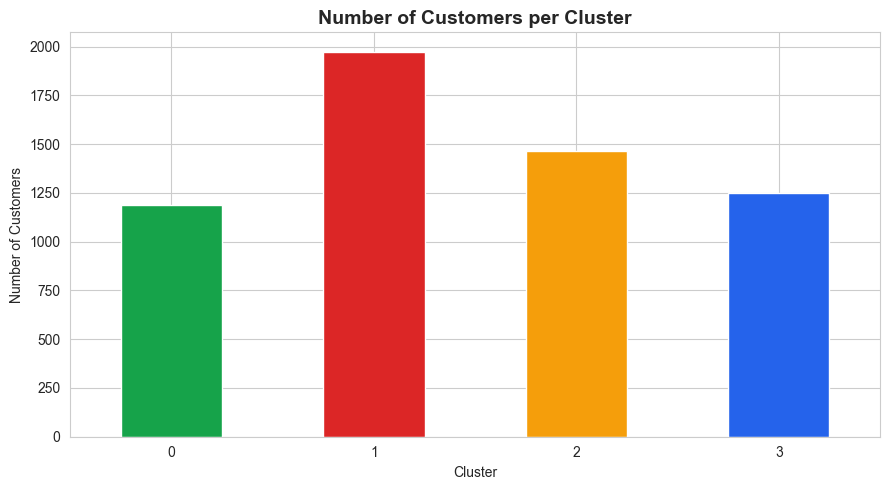

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
labels_map = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}
counts = rfm['Cluster'].value_counts().sort_index()
colors_bar = [palette[i] for i in counts.index]
counts.plot(kind='bar', ax=ax, color=colors_bar)
ax.set_title('Number of Customers per Cluster', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** Cluster sizes are reasonably balanced (ranging from 20.2% to 33.6% of the customer base), meaning no segment is a negligible outlier — every segment identified here represents a meaningful chunk of the customer base worth a distinct marketing approach.

## 11. Insights & Marketing Recommendations

**Champions (20.2% of customers, ~£11,014 avg spend):** These are the most valuable customers — recent, frequent, and high-spending. **Recommendation:** Enroll them in a VIP/loyalty program with early access to new products and exclusive perks. Losing even a few of these customers has an outsized revenue impact, so prioritise retention over acquisition spend here.

**At Risk (24.9% of customers, ~£2,002 avg spend, ~228 days since last purchase):** These customers used to be moderately active but are drifting away. **Recommendation:** Launch a targeted win-back email campaign with a personalised discount or 'we miss you' offer before they fully churn — this segment has proven purchase history, making them cheaper to re-engage than acquiring new customers.

**Promising / New (21.3% of customers, recent but low frequency/spend):** Recently active but haven't built loyalty yet. **Recommendation:** Use onboarding-style nurture campaigns — cross-sell/upsell emails, a 'second purchase' discount, or product recommendations based on their first purchase — to accelerate them toward becoming Champions.

**Hibernating / Lost (33.6% of customers, ~396 days since last purchase, lowest spend):** The largest segment, but the least engaged. **Recommendation:** Rather than heavy investment, use low-cost re-engagement (a single win-back email or seasonal catalogue) — and if there's no response, deprioritise further marketing spend on this group in favour of the other three segments, since the cost of reactivation likely exceeds their probable lifetime value.

**Overall takeaway:** With over half the customer base (33.6% + 24.9% = 58.5%) either dormant or at risk of becoming so, retention-focused marketing (not just new customer acquisition) should be a top priority for this business.